In [1]:
from astropy.table import Table
import galsim
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from astropy.io import fits
import os

In [2]:
cosmos_cat_fname = "/home/adfield/ShearNet/simulated_detection_truth_backcast_unit_fiducial_dec04.fits"
cosmos_cat = Table.read(cosmos_cat_fname)

q_raw   = np.array(cosmos_cat['c10_sersic_fit_q'],  dtype=np.float64)
phi_raw = np.array(cosmos_cat['c10_sersic_fit_phi'], dtype=np.float64)

g1_raw = []
g2_raw = []
for qi, phi_i in zip(q_raw, phi_raw):
    if qi > 1.0:
        qi = 1.0 / qi
    s = galsim.Shear(q=float(qi), beta=float(phi_i) * galsim.radians)
    g1_raw.append(s.g1)
    g2_raw.append(s.g2)
    

g1_raw = np.array(g1_raw)
g2_raw = np.array(g2_raw)

# HLR
hlr_raw = np.array(cosmos_cat['c10_sersic_fit_hlr'], dtype=np.float64) * 0.03 * np.sqrt(q_raw)
hlr_raw = np.minimum(hlr_raw, 1.0)
hlr_raw = np.where(np.isfinite(hlr_raw) & (hlr_raw > 0), hlr_raw, 1e-6)

# Flux
flux_raw = np.array(cosmos_cat['crates_b'], dtype=np.float64) * 300 * 36 / 0.343

# All rows are valid after the HLR clip — nothing is dropped.
valid_mask = np.ones(len(q_raw), dtype=bool)

q_arr     = q_raw[valid_mask]
phi_arr   = phi_raw[valid_mask]
g1_list   = g1_raw[valid_mask]
g2_list   = g2_raw[valid_mask]
hlr_list  = hlr_raw[valid_mask]
flux_list = flux_raw[valid_mask]

n_raw     = len(q_raw)
n_dropped = n_raw - valid_mask.sum()
print(f"Raw catalog rows:       {n_raw}")
print(f"Dropped (invalid HLR):  {n_dropped}")
print(f"Remaining galaxies:     {len(q_arr)}")

Raw catalog rows:       89496
Dropped (invalid HLR):  0
Remaining galaxies:     89496


In [3]:
# ------------------------------------------------------------------
# Augment the catalog: N_AUGMENTS random rotations per galaxy.
# q, hlr, and flux are tiled; phi (and thus g1/g2) is re-drawn
# from a uniform distribution over [0, 2*pi).
# ------------------------------------------------------------------
N_AUGMENTS = 10
rng_aug    = np.random.default_rng(seed=42)
n_gal      = len(q_arr)

# Save pre-augmentation shear for visual comparison below.
g1_pre_aug = g1_list.copy()
g2_pre_aug = g2_list.copy()

# Tile the quantities that are independent of orientation.
q_arr     = np.tile(q_arr,     N_AUGMENTS)
hlr_list  = np.tile(hlr_list,  N_AUGMENTS)
flux_list = np.tile(flux_list, N_AUGMENTS)

# Draw a fresh random position angle for every copy.
phi_arr = rng_aug.uniform(0, 2 * np.pi, size=n_gal * N_AUGMENTS)

g1_list = np.empty(n_gal * N_AUGMENTS)
g2_list = np.empty(n_gal * N_AUGMENTS)
for i in range(n_gal * N_AUGMENTS):
    qi = float(q_arr[i])
    if qi > 1.0:
        qi = 1.0 / qi
    s = galsim.Shear(q=qi, beta=float(phi_arr[i]) * galsim.radians)
    g1_list[i] = s.g1
    g2_list[i] = s.g2

print(f"Original galaxies: {n_gal}")
print(f"Augmented catalog: {len(g1_list)}  ({N_AUGMENTS} rotations each)")

Original galaxies: 89496
Augmented catalog: 894960  (10 rotations each)


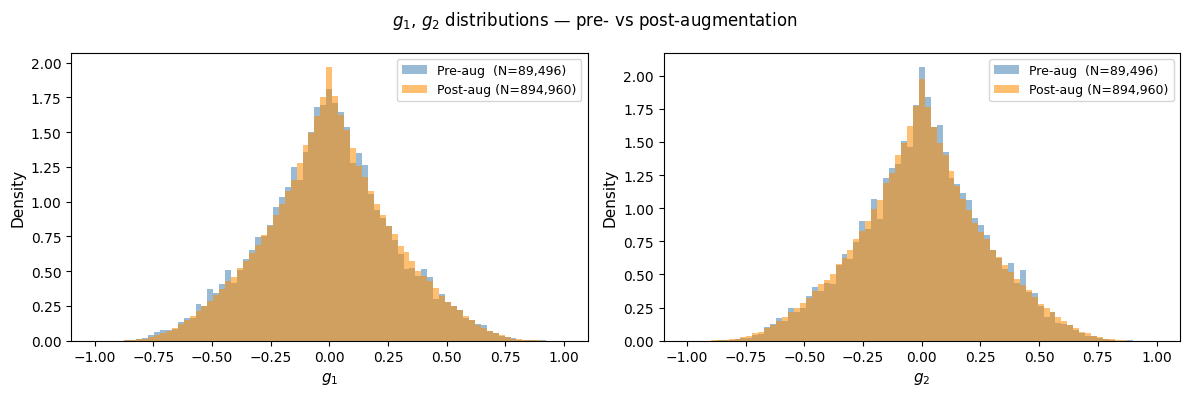

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(r'$g_1$, $g_2$ distributions — pre- vs post-augmentation', fontsize=12)

for ax, pre, post, label in zip(
    axes,
    [g1_pre_aug, g2_pre_aug],
    [g1_list,    g2_list],
    [r'$g_1$',   r'$g_2$'],
):
    bins = np.linspace(-1, 1, 80)
    ax.hist(pre,  bins=bins, density=True, alpha=0.55,
            label=f'Pre-aug  (N={len(pre):,})',  color='steelblue')
    ax.hist(post, bins=bins, density=True, alpha=0.55,
            label=f'Post-aug (N={len(post):,})', color='darkorange')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# Confirm all arrays have the same length after HLR + flux filtering.
# Since we applied valid_mask to every array in the same step, this
# should always pass — but double check before we touch indices.
arrays = {
    'q':    q_arr,
    'phi':  phi_arr,
    'g1':   g1_list,
    'g2':   g2_list,
    'hlr':  hlr_list,
    'flux': flux_list,
}

lengths = {name: len(arr) for name, arr in arrays.items()}
print("Array lengths post-filter:")
for name, n in lengths.items():
    print(f"  {name:<6}: {n}")

assert len(set(lengths.values())) == 1, (
    f"Array length mismatch — cannot split safely!\n{lengths}"
)
print(f"\nAll arrays have length {next(iter(lengths.values()))}. Safe to split.")

Array lengths post-filter:
  q     : 894960
  phi   : 894960
  g1    : 894960
  g2    : 894960
  hlr   : 894960
  flux  : 894960

All arrays have length 894960. Safe to split.


In [6]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

n_total = len(q_arr)
n_train = int(np.round(n_total * 3 / 5))
n_eval  = n_total - n_train

# Shuffle ONE index array — all parameter arrays are sliced identically,
# so galaxy-level correspondence (q_i, phi_i, g1_i, g2_i, hlr_i, flux_i) is preserved.
shuffled_idx = rng.permutation(n_total)
train_idx    = shuffled_idx[:n_train]
eval_idx     = shuffled_idx[n_train:]

print(f"Total:  {n_total}")
print(f"Train:  {n_train}  ({n_train/n_total*100:.1f}%)")
print(f"Eval:   {n_eval}   ({n_eval/n_total*100:.1f}%)")

Total:  894960
Train:  536976  (60.0%)
Eval:   357984   (40.0%)


## Write FITS files

In [7]:
def make_fits_table(idx):
    """Build a FITS BinTableHDU for the given galaxy indices."""
    cols = [
        fits.Column(name='Q',    format='D', array=q_arr[idx],              unit=''),
        fits.Column(name='PHI',  format='D', array=phi_arr[idx],            unit='rad'),
        fits.Column(name='G1',   format='D', array=g1_list[idx],            unit=''),
        fits.Column(name='G2',   format='D', array=g2_list[idx],            unit=''),
        fits.Column(name='HLR',  format='D', array=hlr_list[idx],           unit='arcsec'),
        fits.Column(name='FLUX', format='D', array=flux_list[idx],unit='count'),
    ]
    hdu = fits.BinTableHDU.from_columns(cols)

    hdr = hdu.header
    # FITS keyword comments describe each column
    hdr.comments['TTYPE1'] = 'Axis ratio b/a, (0, 1]'
    hdr.comments['TTYPE2'] = 'Position angle of major axis [rad]'
    hdr.comments['TTYPE3'] = 'Reduced shear component 1'
    hdr.comments['TTYPE4'] = 'Reduced shear component 2'
    hdr.comments['TTYPE5'] = 'Circularized half-light radius [arcsec]'
    hdr.comments['TTYPE6'] = 'Galaxy flux: crates_b * 300 * 36 / 0.343 [count]'

    # Provenance / split metadata
    hdr['RNDSD']   = (RANDOM_SEED,  'RNG seed used for train/eval split')
    hdr['NGAL']    = (len(idx),     'Number of galaxies in this subset')
    hdr['NTOTAL']  = (n_total,      'Total galaxies in augmented catalog')
    hdr['NAUG']    = (N_AUGMENTS,   'Random rotations per source galaxy')
    hdr['ORIGIN']  = ('simulated_detection_truth_backcast_unit_fiducial_dec04.fits',
                      'Source catalog filename')
    return hdu


out_dir = "/home/adfield/ShearNet"

# Training FITS  (3/5)
train_hdu = make_fits_table(train_idx)
train_hdu.header['SUBSET'] = ('TRAIN', '3/5 split - network training')
train_path = os.path.join(out_dir, "cosmos_catalog_train.fits")
train_hdu.writeto(train_path, overwrite=True)
print(f"Wrote training FITS  -> {train_path}")

# Eval FITS  (2/5)
eval_hdu = make_fits_table(eval_idx)
eval_hdu.header['SUBSET'] = ('EVAL', '2/5 split - network evaluation')
eval_path = os.path.join(out_dir, "cosmos_catalog_eval.fits")
eval_hdu.writeto(eval_path, overwrite=True)
print(f"Wrote eval FITS      -> {eval_path}")

Wrote training FITS  -> /home/adfield/ShearNet/cosmos_catalog_train.fits
Wrote eval FITS      -> /home/adfield/ShearNet/cosmos_catalog_eval.fits


/tmp/ipykernel_836079/2021800960.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


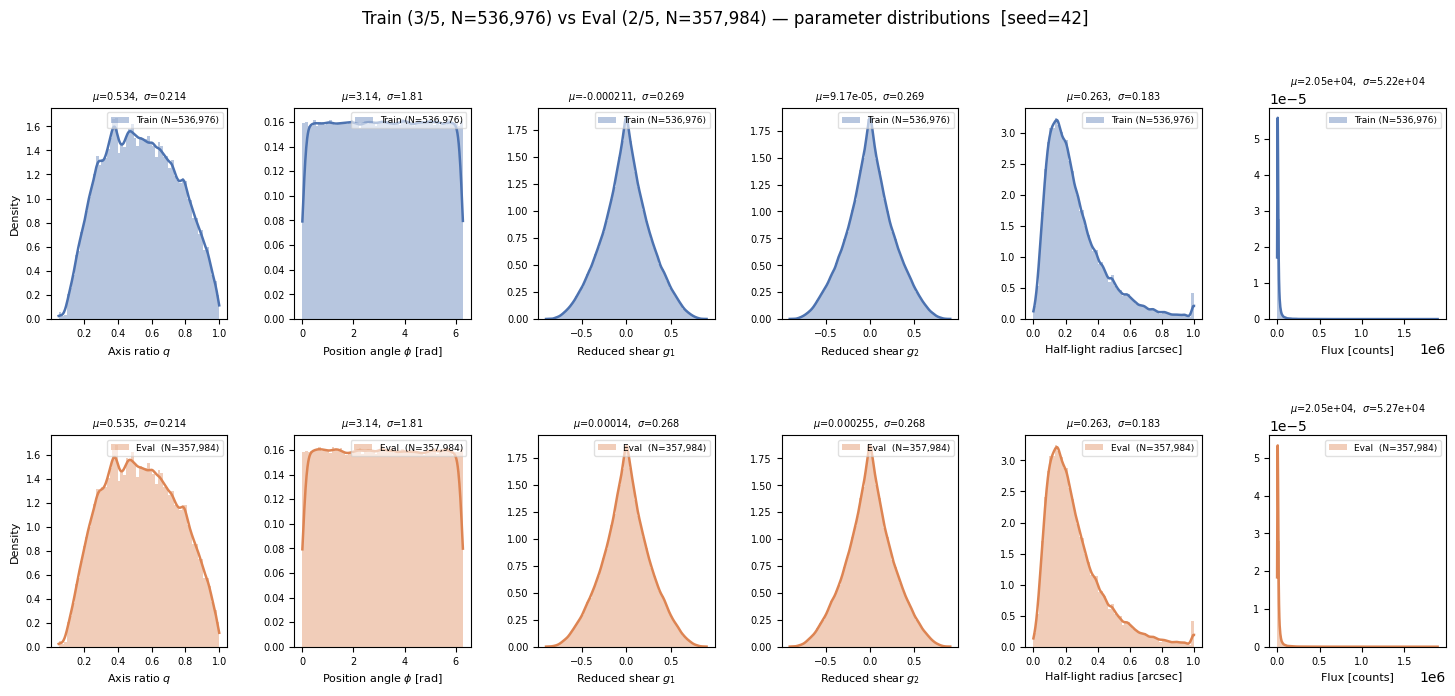

Saved distribution plot -> /home/adfield/ShearNet/catalog_split_distributions.png


In [8]:
params = [
    ('Q',    q_arr,               r'Axis ratio $q$'),
    ('PHI',  phi_arr,             r'Position angle $\phi$ [rad]'),
    ('G1',   g1_list,             r'Reduced shear $g_1$'),
    ('G2',   g2_list,             r'Reduced shear $g_2$'),
    ('HLR',  hlr_list,            r'Half-light radius [arcsec]'),
    ('FLUX', flux_list,            r'Flux [counts]'),
]

TRAIN_COLOR = '#4C72B0'
EVAL_COLOR  = '#DD8452'
N_BINS = 60

fig = plt.figure(figsize=(18, 7))
fig.suptitle(
    f'Train (3/5, N={n_train:,}) vs Eval (2/5, N={n_eval:,}) — parameter distributions'
    f'  [seed={RANDOM_SEED}]',
    fontsize=12, y=1.02
)
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.38)

for col, (name, arr, xlabel) in enumerate(params):
    train_vals = arr[train_idx]
    eval_vals  = arr[eval_idx]

    # Shared bin edges so the two histograms are directly comparable
    lo   = min(train_vals.min(), eval_vals.min())
    hi   = max(train_vals.max(), eval_vals.max())
    bins = np.linspace(lo, hi, N_BINS + 1)
    kde_x = np.linspace(lo, hi, 500)

    for row, (vals, color, split_label) in enumerate([
        (train_vals, TRAIN_COLOR, f'Train (N={n_train:,})'),
        (eval_vals,  EVAL_COLOR,  f'Eval  (N={n_eval:,})'),
    ]):
        ax = fig.add_subplot(gs[row, col])

        ax.hist(vals, bins=bins, density=True, color=color, alpha=0.4,
                label=split_label)

        try:
            kde = gaussian_kde(vals, bw_method='scott')
            ax.plot(kde_x, kde(kde_x), color=color, lw=1.8)
        except np.linalg.LinAlgError:
            pass

        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel('Density' if col == 0 else '', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6.5, loc='upper right', framealpha=0.6)
        ax.set_title(
            fr'$\mu$={vals.mean():.3g},  $\sigma$={vals.std():.3g}',
            fontsize=7
        )

plt.tight_layout()
plot_path = os.path.join(out_dir, "catalog_split_distributions.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved distribution plot -> {plot_path}")

In [9]:
print(f"{'Param':<8}  {'KS stat':>10}  {'p-value':>12}  {'Pass (p>0.05)?'}")
print('-' * 52)
for name, arr, _ in params:
    stat, pval = ks_2samp(arr[train_idx], arr[eval_idx])
    flag = '\u2713' if pval > 0.05 else '\u2717  <-- check this!'
    print(f"{name:<8}  {stat:>10.4f}  {pval:>12.4f}  {flag}")

Param        KS stat       p-value  Pass (p>0.05)?
----------------------------------------------------
Q             0.0020        0.3837  ✓
PHI           0.0019        0.4522  ✓
G1            0.0017        0.5357  ✓
G2            0.0013        0.8634  ✓
HLR           0.0026        0.1032  ✓
FLUX          0.0018        0.5047  ✓
